In [31]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.shape)
print(test.shape)



(1460, 81)
(1459, 80)


In [32]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [33]:
# 資料資訊
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [34]:
# 分析房價
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

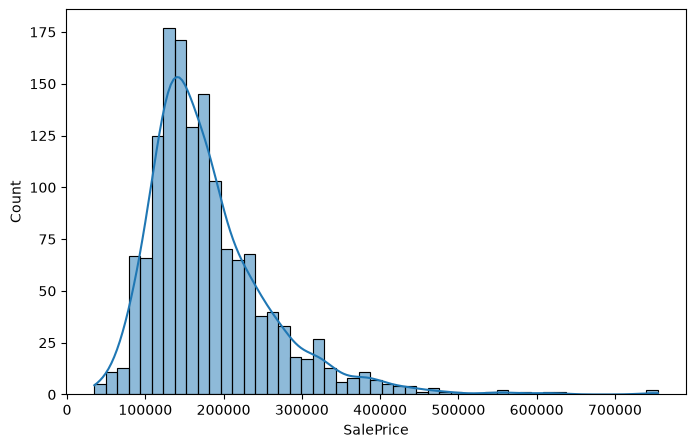

In [35]:
# 房價分布圖
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)

plt.show()

原始偏態：
1.880940746034036


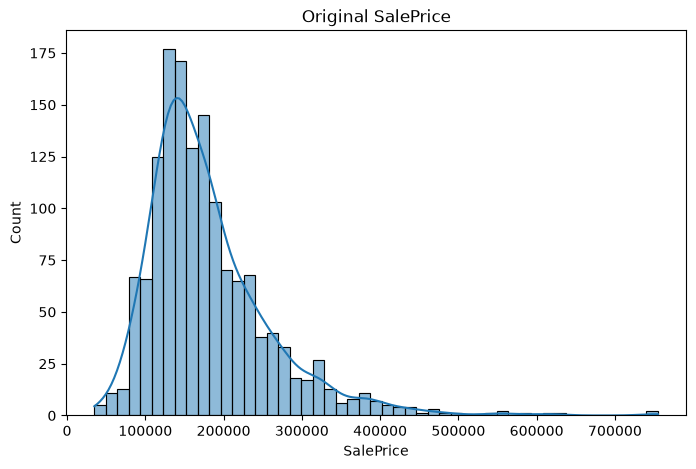

Log後偏態：
0.12122191311528363


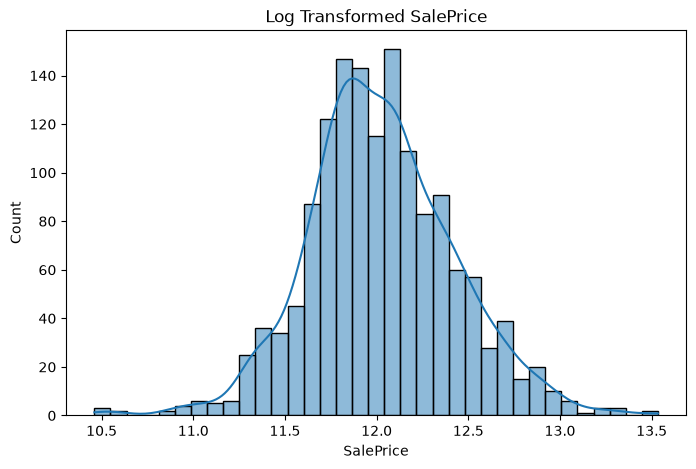

In [36]:
# SalePrice 偏態分析

from scipy.stats import skew
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("原始偏態：")
print(skew(train["SalePrice"]))

plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Original SalePrice")
plt.show()

saleprice_log = np.log1p(train["SalePrice"])

print("Log後偏態：")
print(skew(saleprice_log))

plt.figure(figsize=(8,5))
sns.histplot(saleprice_log, kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

In [37]:
# 找缺失值
missing = train.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [38]:
# 數值欄位相關係數

corr_matrix = train.corr(numeric_only=True)

saleprice_corr = (
    corr_matrix["SalePrice"]
    .sort_values(ascending=False)
)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [39]:
# Correlation Top10分析文字

top_features = (
    saleprice_corr.abs()
    .sort_values(ascending=False)
    .head(10)
)

print(top_features)

print("\n與房價相關性最高的特徵：")
print(top_features.index.tolist())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

與房價相關性最高的特徵：
['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']


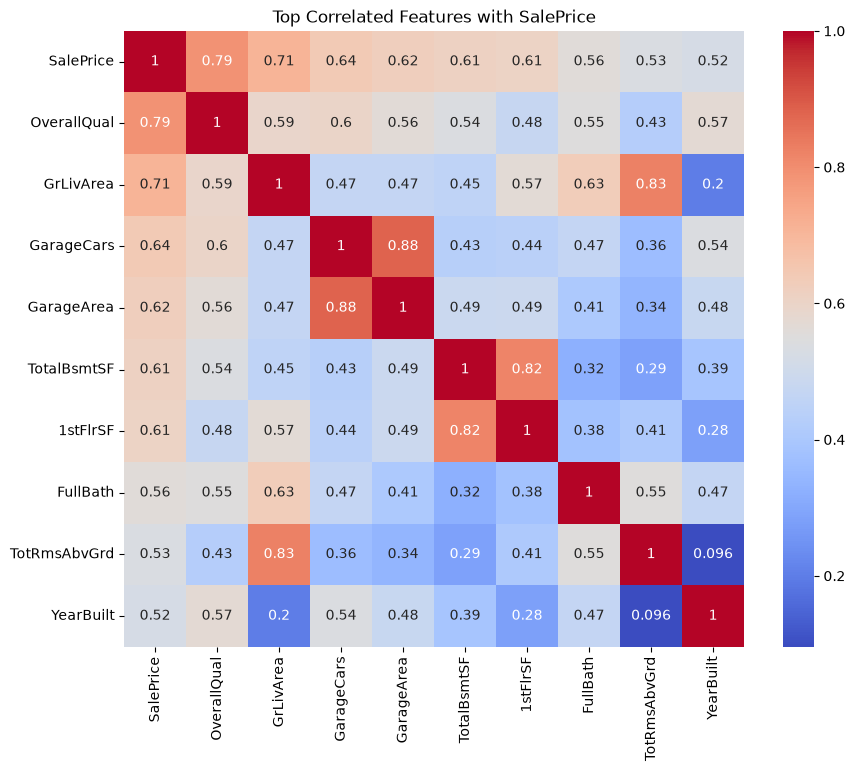

In [40]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

top_features = (
    saleprice_corr.abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10,8))

sns.heatmap(
    train[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Top Correlated Features with SalePrice")

plt.show()

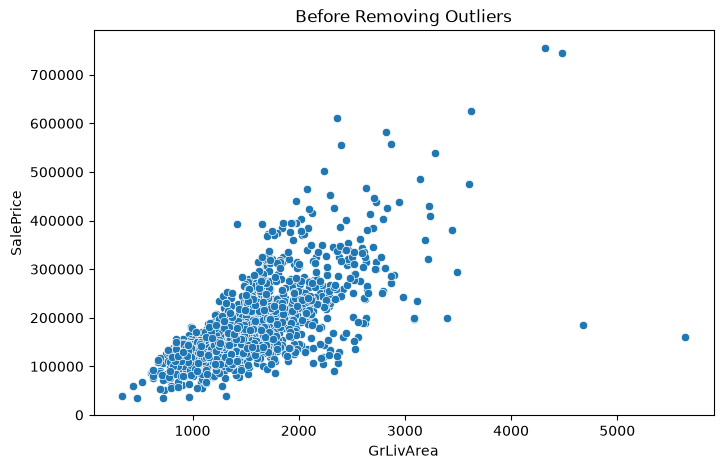

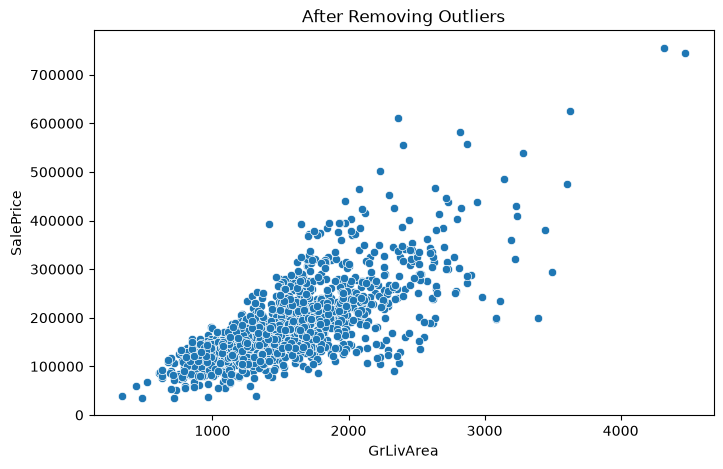

In [41]:
# 刪除前
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)

plt.title("Before Removing Outliers")
plt.show()

# 刪除異常值
train = train.drop(
    train[
        (train["GrLivArea"] > 4000) &
        (train["SalePrice"] < 300000)
    ].index
)

# 刪除後
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)

plt.title("After Removing Outliers")
plt.show()



In [42]:
# 資料前處理與特徵工程

import pandas as pd
import numpy as np

# 1. 目標變數轉換 (對數轉換以處理偏態)
# 提醒：最後輸出 Kaggle 預測檔案或報告計算真實房價誤差時，記得使用 np.expm1() 還原
y_train = np.log1p(train["SalePrice"])

# 為了方便一起處理特徵，先將 train 的 SalePrice 移除，並將 train 與 test 合併
# 同時先捨棄在預測中不需要的 Id 欄位
train_features = train.drop(["SalePrice", "Id"], axis=1)
test_features = test.drop(["Id"], axis=1)

# 將合併後的資料儲存至 all_data
all_data = pd.concat([train_features, test_features]).reset_index(drop=True)
print(f"合併後的資料維度: {all_data.shape}")

# 2. 缺失值填補 (Missing Value Imputation)
# 數值型特徵：LotFrontage 依 Neighborhood 中位數填補，其餘填 0
# 類別型特徵：全部填補為 'None' (代表無此設施)

# 處理 LotFrontage
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# 區分數值型與類別型特徵
numeric_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = all_data.select_dtypes(include=['object']).columns

# 其餘數值特徵填補為 0
numeric_cols = numeric_cols.drop("LotFrontage", errors="ignore")
all_data[numeric_cols] = all_data[numeric_cols].fillna(0)

# 類別特徵填補為 'None'
all_data[categorical_cols] = all_data[categorical_cols].fillna("None")

# 3. 特徵編碼 (One-Hot Encoding)
# 將所有文字類別轉換為數值表示
all_data = pd.get_dummies(all_data)
print(f"One-Hot Encoding 後的資料維度: {all_data.shape}")

# 4. 將資料切分回 train 與 test
# 透過原本 y_train 的長度來切分
X_train = all_data.iloc[:len(y_train), :]
X_test = all_data.iloc[len(y_train):, :]

print(f"處理完畢！X_train 維度: {X_train.shape}, X_test 維度: {X_test.shape}")

合併後的資料維度: (2917, 79)
One-Hot Encoding 後的資料維度: (2917, 309)
處理完畢！X_train 維度: (1458, 309), X_test 維度: (1459, 309)


C:\Users\austi\AppData\Local\Temp\ipykernel_8988\1947762553.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = all_data.select_dtypes(include=['object']).columns


In [43]:
# 建立線性模型與交叉驗證

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# 定義 5 折交叉驗證計算 RMSE 的函數
def rmse_cv(model, X, y):
    # 使用 5-Fold CV，評估指標選用 neg_mean_squared_error，再取平方根
    # 由於 y 已經是取過 log 的房價，這裡計算出來的 RMSE 實質上就是 RMSLE
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5))
    return rmse

# 初始化 Ridge 與 Lasso 模型 (這邊先放上一組示範參數 alpha)
model_ridge = Ridge(alpha=10.0)
model_lasso = Lasso(alpha=0.001)

# 測試模型並印出各個 fold 的平均 RMSE
ridge_rmse = rmse_cv(model_ridge, X_train, y_train).mean()
lasso_rmse = rmse_cv(model_lasso, X_train, y_train).mean()

print(f"Ridge 模型的 5-Fold CV RMSE 評估結果: {ridge_rmse:.5f}")
print(f"Lasso 模型的 5-Fold CV RMSE 評估結果: {lasso_rmse:.5f}")

Ridge 模型的 5-Fold CV RMSE 評估結果: 0.11525
Lasso 模型的 5-Fold CV RMSE 評估結果: 0.11359


In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_rmse = rmse_cv(
    rf_model,
    X_train,
    y_train
).mean()

print(f"Random Forest 5-Fold CV RMSE: {rf_rmse:.5f}")

Random Forest 5-Fold CV RMSE: 0.13809


In [45]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_rmse = rmse_cv(
    xgb_model,
    X_train,
    y_train
).mean()

print(f"XGBoost 5-Fold CV RMSE: {xgb_rmse:.5f}")

ModuleNotFoundError: No module named 'xgboost'